In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_percentage_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [2]:
data = pd.read_csv('NIR_dataset_utf8.csv', 
                   sep=';', 
                   comment='#',
                   low_memory=False,
                   index_col=[0],
                   parse_dates=[0])
data = data.drop('Unnamed: 29', axis=1)

print(data.info())
data.head()

C:\Users\HUAWEI\AppData\Local\Temp\ipykernel_8896\2812101743.py:1: UserWarning: Parsing dates in %d.%m.%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data = pd.read_csv('NIR_dataset_utf8.csv',


<class 'pandas.DataFrame'>
DatetimeIndex: 47455 entries, 2026-04-27 12:00:00 to 2009-03-25 21:00:00
Data columns (total 28 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   T       47432 non-null  float64
 1   Po      47001 non-null  float64
 2   P       47424 non-null  float64
 3   Pa      38243 non-null  float64
 4   U       47418 non-null  float64
 5   DD      47393 non-null  str    
 6   Ff      47397 non-null  float64
 7   ff10    35 non-null     float64
 8   ff3     399 non-null    float64
 9   N       47379 non-null  str    
 10  WW      47455 non-null  str    
 11  W1      15060 non-null  str    
 12  W2      15060 non-null  str    
 13  Tn      7955 non-null   float64
 14  Tx      6160 non-null   float64
 15  Cl      37240 non-null  str    
 16  Nh      37863 non-null  str    
 17  H       37968 non-null  str    
 18  Cm      24358 non-null  str    
 19  Ch      20787 non-null  str    
 20  VV      47389 non-null  str    
 21  Td      474

,T,Po,P,Pa,U,DD,Ff,ff10,ff3,N,...,Cm,Ch,VV,Td,RRR,tR,E,Tg,E',sss
Время,,,,,,,,,,,,,,,,,,,,,
2026-04-27 12:00:00,12.3,713.5,763.2,1.3,58.0,"Ветер, дующий с западо-юго-запада",3.0,NaN,NaN,100%.,...,NaN,NaN,20.0,4.3,NaN,NaN,NaN,NaN,NaN,NaN
2026-04-27 09:00:00,10.8,712.2,762.1,0.8,72.0,"Штиль, безветрие",0.0,NaN,NaN,100%.,...,NaN,NaN,20.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN
2026-04-27 06:00:00,9.1,711.4,761.6,0.4,77.0,"Ветер, дующий с севера",1.0,NaN,NaN,100%.,...,"Высококучевые, просвечивающие или плотные в дв...",NaN,20.0,5.3,0.1,12.0,Поверхность почвы влажная.,8.0,NaN,NaN
2026-04-27 03:00:00,10.1,711.0,760.9,0.9,70.0,"Ветер, дующий с северо-востока",2.0,NaN,NaN,100%.,...,"Высококучевые просвечивающие, полосами, либо о...",NaN,20.0,4.9,NaN,NaN,NaN,NaN,NaN,NaN
2026-04-27 00:00:00,10.8,710.1,759.8,0.0,64.0,"Ветер, дующий с севера",1.0,NaN,NaN,40%.,...,"Высококучевые, просвечивающие или плотные в дв...","Перистых, перисто-кучевых или перисто-слоистых...",20.0,4.3,NaN,NaN,NaN,NaN,NaN,NaN



Ниже приведены столбцы из таблицы архива погоды и их определения, взятые непосредственно со страницы `http://rp5.ru/archive.php?wmo_id=37107&lang=ru`.

| Столбец | Короткое определение |
| :--- | :--- |
| **Дата / Местное время** | Дата и время наблюдения (местное). |
| **T** | Температура воздуха (градусы Цельсия) на высоте 2 метра над поверхностью земли. |
| **Po** | Атмосферное давление на уровне станции (миллиметры ртутного столба). |
| **P** | Атмосферное давление, приведенное к среднему уровню моря (миллиметры ртутного столба). |
| **Pa** | Изменение атмосферного давления за последние три часа(миллиметры ртутного столба). |
| **U** | Относительная влажность (%) на высоте 2 метра над поверхностью земли. |
| **DD** | Направление ветра (румбы) на высоте 10-12 метров над земной поверхностью, осредненное за 10-минутный период, непосредственно предшествовавший сроку наблюдения. |
| **Ff** | Скорость ветра на высоте 10-12 метров над земной поверхностью, осредненная за 10-минутный период, непосредственно предшествовавший сроку наблюдения (метры в секунду). |
| **ff10** | Максимальное значение порыва ветра на высоте 10-12 метров над земной поверхностью за 10-минутный период, непосредственно предшествующий сроку наблюдения (метры в секунду). |
| **ff3** | Максимальное значение порыва ветра на высоте 10-12 метров над земной поверхностью за период между сроками (метры в секунду). |
| **N** | Общая облачность. |
| **WW** | Текущая погода, сообщаемая с метеорологической станции. |
| **W1** | Прошедшая погода между сроками наблюдения 1 |
| **W2** | Прошедшая погода между сроками наблюдения 2 |
| **Tn** | Минимальная температура воздуха (градусы Цельсия) за прошедший период (не более 12 часов). |
| **Tx** | Максимальная температура воздуха (градусы Цельсия) за прошедший период (не более 12 часов). |
| **Cl** | Слоисто-кучевые, слоистые, кучевые и кучево-дождевые облака |
| **Nh** | Количество всех наблюдающихся облаков Cl или, при отсутствии облаков Cl, количество всех наблюдающихся облаков Cm. |
| **H** | Высота основания самых низких облаков (м). |
| **Cm** | Высококучевые, высокослоистые и слоисто-дождевые облака |
| **Ch** | Перистые, перисто-кучевые и перисто-слоистые облака |
| **VV** | Горизонтальная дальность видимости (км). |
| **Td** | Температура точки росы на высоте 2 метра над поверхностью земли (градусы Цельсия) |
| **RRR** | Количество выпавших осадков (миллиметры). |
| **tR** | Период времени, за который накоплено указанное количество осадков (часы) |
| **E** | Состояние поверхности почвы без снега или измеримого ледяного покрова |
| **Tg** | Минимальная температура поверхности почвы за ночь. (градусы Цельсия) |
| **E'** | Состояние поверхности почвы со снегом или измеримым ледяным покровом |
| **sss** | Высота снежного покрова (см). |


In [3]:
data = data.drop(['WW','W1','W2','Cl','Nh','H','Cm','Ch','E','Tg',"E'",'ff10','ff3','Po','Pa'], axis=1)

In [4]:
print(data.info())
data.head()


<class 'pandas.DataFrame'>
DatetimeIndex: 47455 entries, 2026-04-27 12:00:00 to 2009-03-25 21:00:00
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   T       47432 non-null  float64
 1   P       47424 non-null  float64
 2   U       47418 non-null  float64
 3   DD      47393 non-null  str    
 4   Ff      47397 non-null  float64
 5   N       47379 non-null  str    
 6   Tn      7955 non-null   float64
 7   Tx      6160 non-null   float64
 8   VV      47389 non-null  str    
 9   Td      47436 non-null  float64
 10  RRR     10706 non-null  str    
 11  tR      10706 non-null  float64
 12  sss     980 non-null    str    
dtypes: float64(8), str(5)
memory usage: 5.1 MB
None


,T,P,U,DD,Ff,N,Tn,Tx,VV,Td,RRR,tR,sss
Время,,,,,,,,,,,,,
2026-04-27 12:00:00,12.3,763.2,58.0,"Ветер, дующий с западо-юго-запада",3.0,100%.,NaN,NaN,20.0,4.3,NaN,NaN,NaN
2026-04-27 09:00:00,10.8,762.1,72.0,"Штиль, безветрие",0.0,100%.,9.0,NaN,20.0,6.0,NaN,NaN,NaN
2026-04-27 06:00:00,9.1,761.6,77.0,"Ветер, дующий с севера",1.0,100%.,9.1,NaN,20.0,5.3,0.1,12.0,NaN
2026-04-27 03:00:00,10.1,760.9,70.0,"Ветер, дующий с северо-востока",2.0,100%.,NaN,NaN,20.0,4.9,NaN,NaN,NaN
2026-04-27 00:00:00,10.8,759.8,64.0,"Ветер, дующий с севера",1.0,40%.,NaN,NaN,20.0,4.3,NaN,NaN,NaN


In [5]:
data['DD'].unique()

<StringArray>
[     'Ветер, дующий с западо-юго-запада',
                       'Штиль, безветрие',
                 'Ветер, дующий с севера',
         'Ветер, дующий с северо-востока',
          'Ветер, дующий с северо-запада',
             'Ветер, дующий с юго-запада',
                'Ветер, дующий с востока',
 'Ветер, дующий с востоко-северо-востока',
  'Ветер, дующий с северо-северо-востока',
                 'Ветер, дующий с запада',
            'Ветер, дующий с юго-востока',
    'Ветер, дующий с востоко-юго-востока',
         'Ветер, дующий с юго-юго-запада',
   'Ветер, дующий с северо-северо-запада',
                    'Ветер, дующий с юга',
   'Ветер, дующий с западо-северо-запада',
        'Ветер, дующий с юго-юго-востока',
                                      nan]
Length: 18, dtype: str

In [6]:
data['DD'] = data['DD'].map({'Ветер, дующий с западо-юго-запада':-1,
                       'Штиль, безветрие': 0,
                 'Ветер, дующий с севера': 4,
         'Ветер, дующий с северо-востока':2,
          'Ветер, дующий с северо-запада':2,
             'Ветер, дующий с юго-запада':-2,
                'Ветер, дующий с востока':0,
 'Ветер, дующий с востоко-северо-востока':1,
  'Ветер, дующий с северо-северо-востока':3,
                 'Ветер, дующий с запада':0,
            'Ветер, дующий с юго-востока':-2,
    'Ветер, дующий с востоко-юго-востока':-1,
         'Ветер, дующий с юго-юго-запада':-3,
   'Ветер, дующий с северо-северо-запада':3,
                    'Ветер, дующий с юга':-4,
   'Ветер, дующий с западо-северо-запада':1,
        'Ветер, дующий с юго-юго-востока':-3})

In [7]:
data['N'].unique()

<StringArray>
[                                                             '100%.',
                                                               '40%.',
                                                          '70 – 80%.',
                                            '10%  или менее, но не 0',
                                                       'Облаков нет.',
                                                               '60%.',
                                          '90  или более, но не 100%',
                                                            '20–30%.',
 'Небо не видно из-за тумана и/или других метеорологических явлений.',
                                                                  nan,
                                                               '50%.']
Length: 11, dtype: str

In [8]:
data['N'] = data['N'].map({'90  или более, но не 100%': 95, '100%.': 100, '60%.': 60, '70 – 80%.': 75, 'Облаков нет.': 0, '50%.': 50, '40%.': 40,
        '20–30%.': 25, 'Небо не видно из-за тумана и/или других метеорологических явлений.': -1, '10%  или менее, но не 0': 5})

In [9]:
data['VV'].unique()

<StringArray>
[     '20.0',      '18.0',      '19.0',      '12.0',      '14.0',       '9.0',
      '13.0',       '8.0',       '6.0',       '7.0',      '10.0',      '16.0',
      '17.0',      '11.0',      '15.0',       '4.1',       '4.2',       '2.2',
       '5.0',       '4.3',       '4.6',       '2.5',       '2.1',       '3.7',
       '4.4',       '4.5',       '0.4',       '0.3',       '1.1',       '1.0',
       '0.8',       '0.7',       '1.9',       '3.3',       '0.5',       '2.3',
       '3.5',       '2.7',       '4.0',       '2.6',       '1.6',       '3.0',
       '3.2',       '3.4',       '3.8',       '3.6',       '1.7',       '1.8',
       '1.2',       '2.0',       '3.1',       '1.4',       '0.2',       '4.7',
       '1.3',       '1.5',       '2.4',      '50.0',       '2.8',       '4.8',
       '4.9',       '0.9',       '2.9',       '0.6',       '3.9',       '0.1',
      '71.0',         nan,      '21.0',      '40.0', 'менее 0.1',      '0.05',
      '29.0']
Length: 73, dtype: str

In [10]:
data['VV'] = data['VV'].replace({'менее 0.1': '0.05'}).astype(str).str.replace(',', '.').dropna()
data['VV'] = pd.to_numeric(data['VV'], errors='coerce')

In [11]:
data['RRR'].unique()

<StringArray>
[            nan,           '0.1',   'Осадков нет',          '15.0',
           '5.0',           '7.0',          '12.0',          '20.0',
          '17.0',           '2.0',           '6.0',          '11.0',
          '16.0',           '0.5',           '4.0',          '13.0',
           '0.3',           '0.7',           '1.0',          '10.0',
           '0.8',           '9.0',           '3.0',           '0.4',
           '0.2',          '18.0', 'Следы осадков',          '19.0',
          '28.0',          '23.0',          '22.0',          '21.0',
          '26.0',           '8.0',          '24.0',          '14.0',
          '27.0',          '38.0',          '31.0',          '34.0',
          '30.0',           '0.6',          '54.0',          '42.0',
          '37.0',          '45.0',          '29.0',           '0.9',
          '44.0',          '33.0',          '63.0',          '32.0',
          '62.0',          '51.0',          '71.0',          '36.0',
          '25.0',   

In [12]:
data['RRR'] = data['RRR'].replace({'Осадков нет': '0', 'Следы осадков': '0.05'}).astype(str).str.replace(',', '.').dropna()
data['RRR'] = pd.to_numeric(data['RRR'], errors='coerce')

In [13]:
data['sss'].unique()

<StringArray>
[        nan,       '1.0',       '4.0',       '2.0',       '9.0',      '25.0',
       '3.0',       '7.0',       '8.0',      '11.0',      '12.0',      '13.0',
      '15.0',      '17.0',      '18.0',      '20.0',      '21.0',      '23.0',
      '26.0',      '29.0',      '31.0',      '33.0',      '35.0',      '43.0',
      '44.0',      '40.0',      '48.0',      '50.0',      '55.0',      '52.0',
      '57.0',      '62.0',      '39.0',      '42.0',      '24.0',      '46.0',
      '47.0',      '58.0',      '69.0',      '81.0',      '86.0',      '96.0',
     '103.0',     '108.0',      '77.0',       '5.0',       '6.0',      '27.0',
      '36.0',      '38.0',      '51.0',      '54.0',      '45.0',      '53.0',
      '10.0',      '14.0',      '19.0',      '22.0',      '56.0',      '60.0',
      '30.0', 'Менее 0.5',      '32.0',      '34.0',      '80.0',      '66.0',
      '59.0',      '49.0',      '65.0',      '68.0',      '16.0',      '28.0',
      '41.0',      '73.0',      '63.0'

In [14]:
data['sss'] = data['sss'].replace({'Менее 0.5': '0.25'}).astype(str).str.replace(',', '.').dropna()
data['sss'] = pd.to_numeric(data['sss'], errors='coerce')

In [15]:
print(data.info())
data.head(15)

<class 'pandas.DataFrame'>
DatetimeIndex: 47455 entries, 2026-04-27 12:00:00 to 2009-03-25 21:00:00
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   T       47432 non-null  float64
 1   P       47424 non-null  float64
 2   U       47418 non-null  float64
 3   DD      47393 non-null  float64
 4   Ff      47397 non-null  float64
 5   N       47379 non-null  float64
 6   Tn      7955 non-null   float64
 7   Tx      6160 non-null   float64
 8   VV      47389 non-null  float64
 9   Td      47436 non-null  float64
 10  RRR     10706 non-null  float64
 11  tR      10706 non-null  float64
 12  sss     980 non-null    float64
dtypes: float64(13)
memory usage: 5.1 MB
None


,T,P,U,DD,Ff,N,Tn,Tx,VV,Td,RRR,tR,sss
Время,,,,,,,,,,,,,
2026-04-27 12:00:00,12.3,763.2,58.0,-1.0,3.0,100.0,NaN,NaN,20.0,4.3,NaN,NaN,NaN
2026-04-27 09:00:00,10.8,762.1,72.0,0.0,0.0,100.0,9.0,NaN,20.0,6.0,NaN,NaN,NaN
2026-04-27 06:00:00,9.1,761.6,77.0,4.0,1.0,100.0,9.1,NaN,20.0,5.3,0.1,12.0,NaN
2026-04-27 03:00:00,10.1,760.9,70.0,2.0,2.0,100.0,NaN,NaN,20.0,4.9,NaN,NaN,NaN
2026-04-27 00:00:00,10.8,759.8,64.0,4.0,1.0,40.0,NaN,NaN,20.0,4.3,NaN,NaN,NaN
2026-04-26 21:00:00,13.4,759.4,55.0,4.0,2.0,75.0,NaN,NaN,20.0,4.5,NaN,NaN,NaN
2026-04-26 18:00:00,17.2,757.6,42.0,2.0,2.0,5.0,NaN,23.5,20.0,4.2,0.0,12.0,NaN
2026-04-26 15:00:00,23.3,757.0,25.0,-2.0,3.0,0.0,NaN,NaN,18.0,2.2,NaN,NaN,NaN
2026-04-26 12:00:00,19.8,759.4,31.0,-2.0,2.0,0.0,NaN,NaN,20.0,2.2,NaN,NaN,NaN


In [16]:
df = data.resample('D').agg({
    'T': 'mean', 
    'P': 'mean',
    'U': 'mean',
    'DD': 'mean',
    'Ff': 'mean',
    'N':'mean',
    'Tn': 'sum',
    'Tx': 'sum',
    'VV': 'mean',
    'Td': 'mean',
    'RRR': 'sum',  
    'tR': 'sum',
    'sss': 'sum'
})


In [17]:
df.isna().sum()

T      1
P      1
U      1
DD     1
Ff     1
N      1
Tn     0
Tx     0
VV     1
Td     1
RRR    0
tR     0
sss    0
dtype: int64

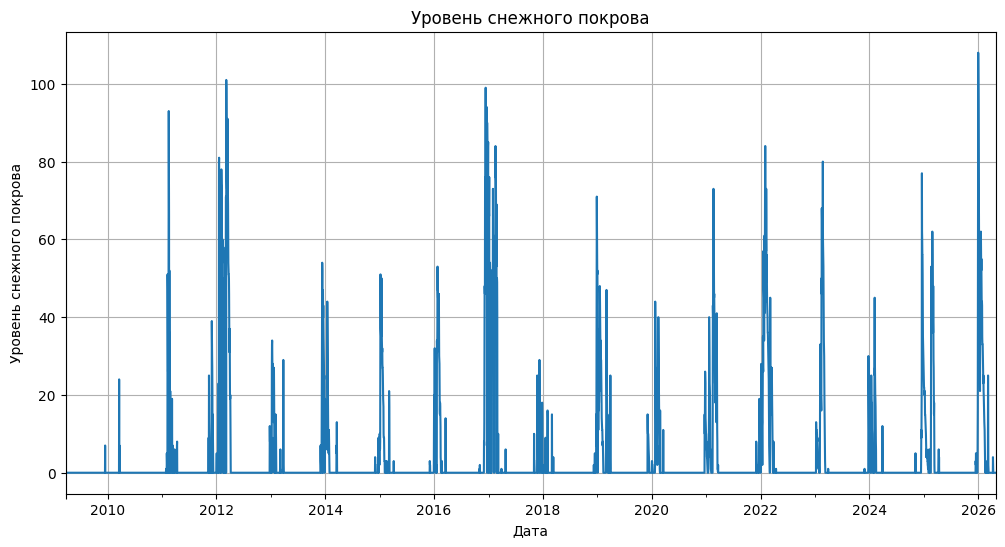

In [18]:
df['sss'].plot(figsize=(12,6))
plt.title('Уровень снежного покрова')
plt.xlabel('Дата')
plt.ylabel('Уровень снежного покрова')
plt.grid(True)
plt.show()

In [19]:
df_daily = df.copy()

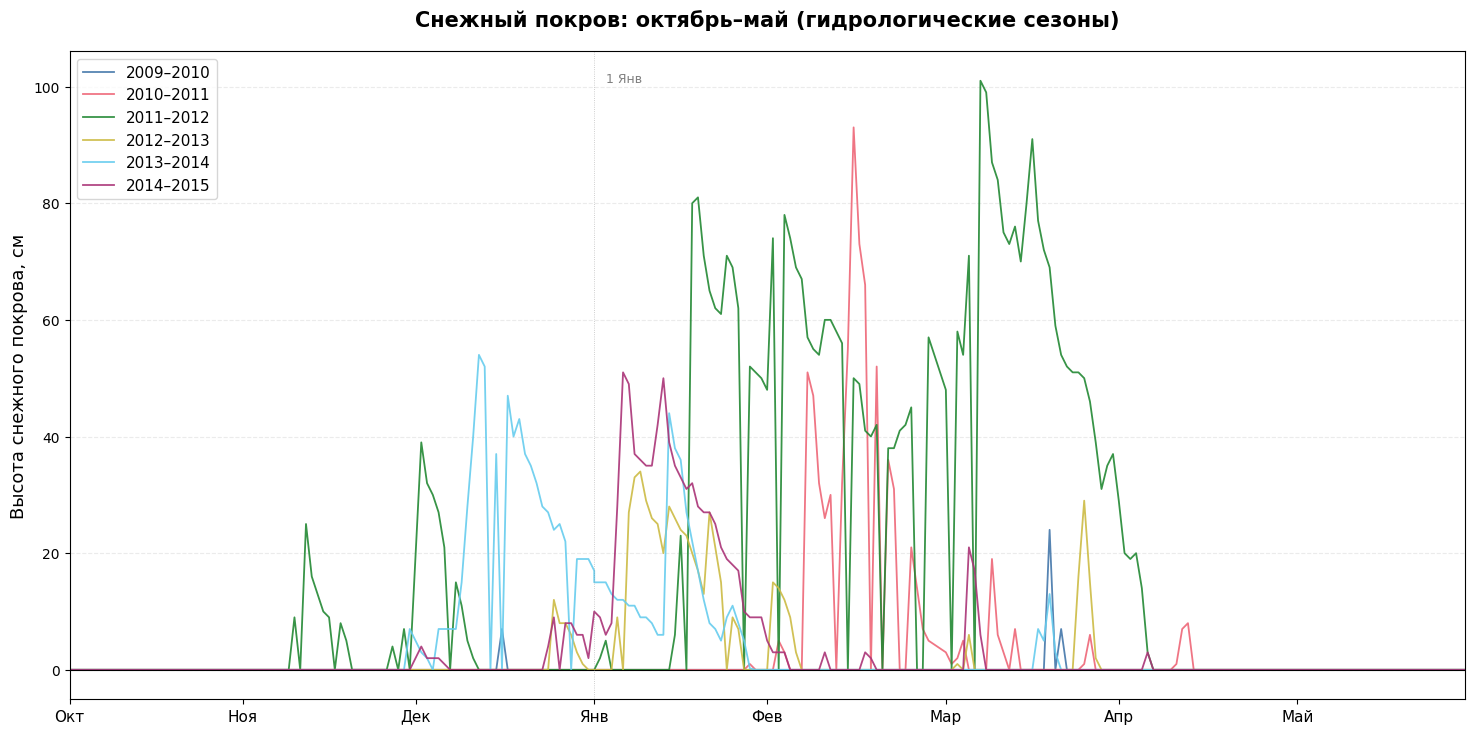

In [20]:
df['year'] = df.index.year
df['month'] = df.index.month
df['day'] = df.index.day

# Убираем 29 февраля
df = df[~((df.index.month == 2) & (df.index.day == 29))]

# ---------------------------------------------------
# 2. ГИДРОЛОГИЧЕСКИЙ ГОД (сезон сентябрь–август)
# ---------------------------------------------------
df['season'] = np.where(df['month'] >= 9, 
                         df['year'].astype(str) + '–' + (df['year'] + 1).astype(str),
                         (df['year'] - 1).astype(str) + '–' + df['year'].astype(str))

# День сезона: 1 сентября = день 1
df['season_day'] = np.where(
    df['month'] >= 9,
    (df['month'] - 9) * 30.44 + df['day'],
    (df['month'] + 3) * 30.44 + df['day']
).astype(int)

# ---------------------------------------------------
# 3. ОСТАВЛЯЕМ ТОЛЬКО ОКТЯБРЬ–МАЙ
# ---------------------------------------------------
# В сезонных днях:
# Сентябрь: 1–30
# Октябрь:  31–60
# ...
# Май:     244–273
OCTOBER_START = 31    # 1 октября (примерно)
MAY_END = 273         # 31 мая (примерно)

df_season = df[(df['season_day'] >= OCTOBER_START) & (df['season_day'] <= MAY_END)]

# ---------------------------------------------------
# 4. НАСТРОЙКА — выбираем сезоны
# ---------------------------------------------------
all_seasons = sorted(df_season['season'].unique(), key=lambda s: int(s[:4]))
seasons = all_seasons[1:7]   

# Paul Tol "Bright" — 7 контрастных цветов
paul_tol_bright = [
    '#4477AA',  # синий
    '#EE6677',  # красный
    '#228833',  # зелёный
    '#CCBB44',  # жёлтый
    '#66CCEE',  # голубой
    '#AA3377',  # пурпурный
    '#BBBBBB',  # серый
]

# Выбираем нужное количество
colors = paul_tol_bright[:len(seasons)]


# ---------------------------------------------------
# 5. ПОСТРОЕНИЕ ГРАФИКА
# ---------------------------------------------------
fig, ax = plt.subplots(figsize=(18, 8))

for i, season in enumerate(seasons):
    seasondata = df[df['season'] == season].sort_values('season_day')
    
    if len(seasondata) < 15:
        continue
    
    ax.plot(seasondata['season_day'], 
            seasondata['sss'], 
            color=colors[i],
            linewidth=1.3,
            alpha=0.9,
            label=season)

# ---------------------------------------------------
# 6. ОСИ И МЕТКИ (только октябрь–май)
# ---------------------------------------------------
# Месяцы: Окт=31, Ноя=61, Дек=91, Янв=122, Фев=152, Мар=183, Апр=213, Май=244
month_starts = [31, 61, 91, 122, 152, 183, 213, 244]
month_labels = ['Окт', 'Ноя', 'Дек', 'Янв', 'Фев', 'Мар', 'Апр', 'Май']

ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels, fontsize=11)
ax.set_xlim(OCTOBER_START, MAY_END)

ax.set_ylabel('Высота снежного покрова, см', fontsize=13)
ax.set_title('Снежный покров: октябрь–май (гидрологические сезоны)', 
             fontsize=15, pad=18, fontweight='bold')

# Горизонтальная нулевая линия
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')

# Вертикальная линия на 1 января
ax.axvline(x=122, color='gray', linewidth=0.6, linestyle=':', alpha=0.5)
ax.text(124, ax.get_ylim()[1] * 0.95, '1 Янв', fontsize=9, color='gray')

# Сетка
ax.grid(True, linestyle='--', alpha=0.25, axis='y')

# ---------------------------------------------------
# 7. ЛЕГЕНДА
# ---------------------------------------------------
ax.legend(
    fontsize=11, 
    loc='upper left'
)

plt.subplots_adjust(top=0.92)
plt.show()

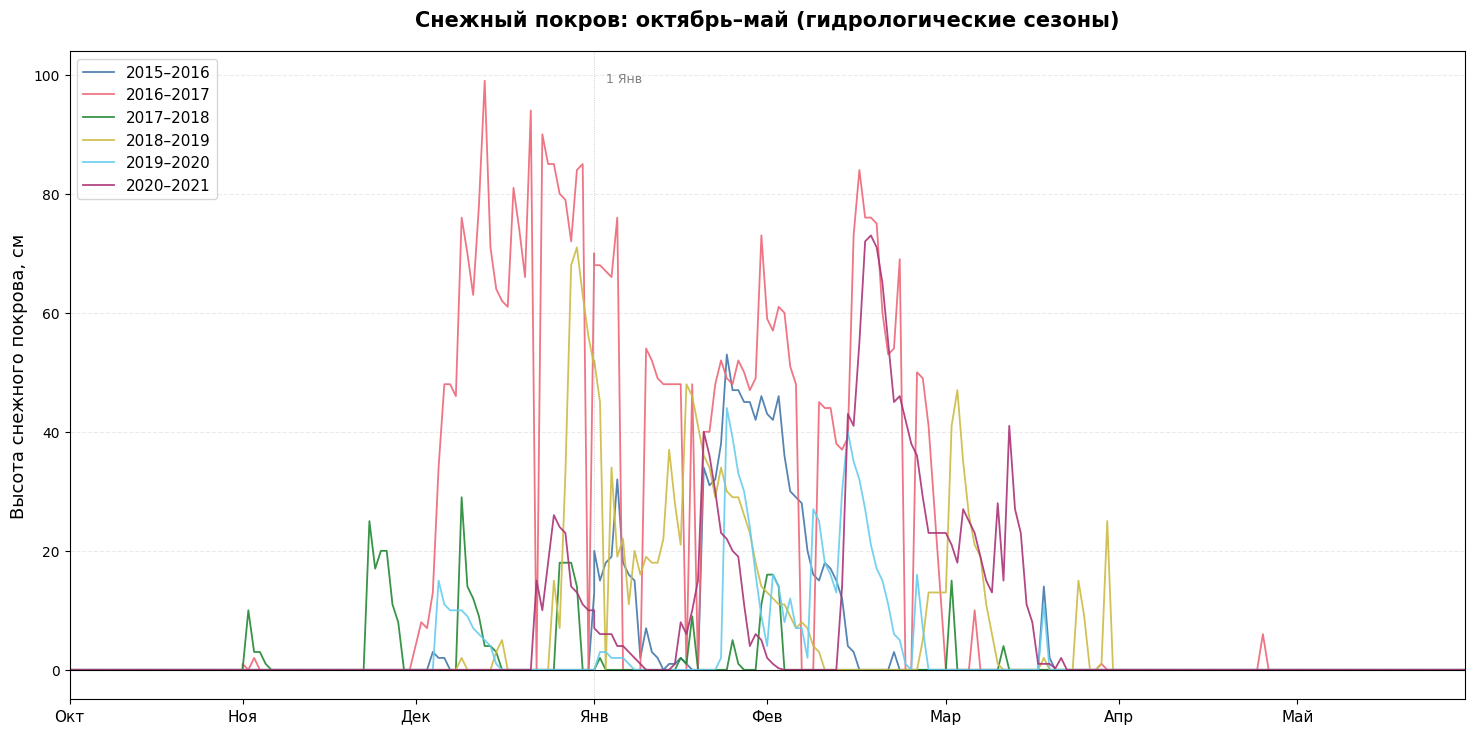

In [21]:

seasons = all_seasons[7:13]  

# Paul Tol "Bright" — 7 контрастных цветов
paul_tol_bright = [
    '#4477AA',  # синий
    '#EE6677',  # красный
    '#228833',  # зелёный
    '#CCBB44',  # жёлтый
    '#66CCEE',  # голубой
    '#AA3377',  # пурпурный
    '#BBBBBB',  # серый
]

# Выбираем нужное количество
colors = paul_tol_bright[:len(seasons)]


# ---------------------------------------------------
# 5. ПОСТРОЕНИЕ ГРАФИКА
# ---------------------------------------------------
fig, ax = plt.subplots(figsize=(18, 8))

for i, season in enumerate(seasons):
    seasondata = df[df['season'] == season].sort_values('season_day')
    
    if len(seasondata) < 15:
        continue
    
    ax.plot(seasondata['season_day'], 
            seasondata['sss'], 
            color=colors[i],
            linewidth=1.3,
            alpha=0.9,
            label=season)

# ---------------------------------------------------
# 6. ОСИ И МЕТКИ (только октябрь–май)
# ---------------------------------------------------
# Месяцы: Окт=31, Ноя=61, Дек=91, Янв=122, Фев=152, Мар=183, Апр=213, Май=244
month_starts = [31, 61, 91, 122, 152, 183, 213, 244]
month_labels = ['Окт', 'Ноя', 'Дек', 'Янв', 'Фев', 'Мар', 'Апр', 'Май']

ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels, fontsize=11)
ax.set_xlim(OCTOBER_START, MAY_END)

ax.set_ylabel('Высота снежного покрова, см', fontsize=13)
ax.set_title('Снежный покров: октябрь–май (гидрологические сезоны)', 
             fontsize=15, pad=18, fontweight='bold')

# Горизонтальная нулевая линия
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')

# Вертикальная линия на 1 января
ax.axvline(x=122, color='gray', linewidth=0.6, linestyle=':', alpha=0.5)
ax.text(124, ax.get_ylim()[1] * 0.95, '1 Янв', fontsize=9, color='gray')

# Сетка
ax.grid(True, linestyle='--', alpha=0.25, axis='y')

# ---------------------------------------------------
# 7. ЛЕГЕНДА
# ---------------------------------------------------
ax.legend(
    fontsize=11, 
    loc='upper left'
)

plt.subplots_adjust(top=0.92)
plt.show()

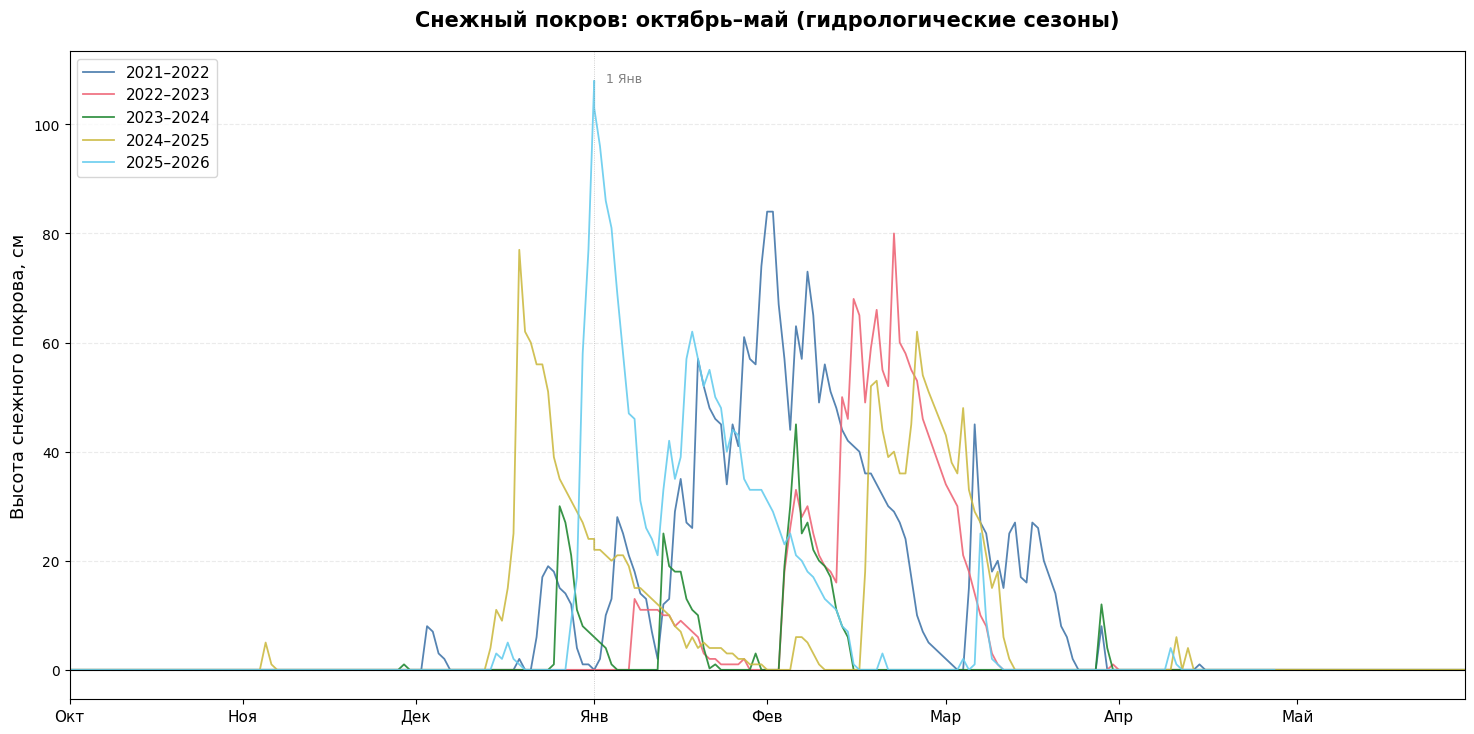

In [22]:

seasons = all_seasons[13:] 

# Paul Tol "Bright" — 7 контрастных цветов
paul_tol_bright = [
    '#4477AA',  # синий
    '#EE6677',  # красный
    '#228833',  # зелёный
    '#CCBB44',  # жёлтый
    '#66CCEE',  # голубой
    '#AA3377',  # пурпурный
    '#BBBBBB',  # серый
]

# Выбираем нужное количество
colors = paul_tol_bright[:len(seasons)]


# ---------------------------------------------------
# 5. ПОСТРОЕНИЕ ГРАФИКА
# ---------------------------------------------------
fig, ax = plt.subplots(figsize=(18, 8))

for i, season in enumerate(seasons):
    seasondata = df[df['season'] == season].sort_values('season_day')
    
    if len(seasondata) < 15:
        continue
    
    ax.plot(seasondata['season_day'], 
            seasondata['sss'], 
            color=colors[i],
            linewidth=1.3,
            alpha=0.9,
            label=season)

# ---------------------------------------------------
# 6. ОСИ И МЕТКИ (только октябрь–май)
# ---------------------------------------------------
# Месяцы: Окт=31, Ноя=61, Дек=91, Янв=122, Фев=152, Мар=183, Апр=213, Май=244
month_starts = [31, 61, 91, 122, 152, 183, 213, 244]
month_labels = ['Окт', 'Ноя', 'Дек', 'Янв', 'Фев', 'Мар', 'Апр', 'Май']

ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels, fontsize=11)
ax.set_xlim(OCTOBER_START, MAY_END)

ax.set_ylabel('Высота снежного покрова, см', fontsize=13)
ax.set_title('Снежный покров: октябрь–май (гидрологические сезоны)', 
             fontsize=15, pad=18, fontweight='bold')

# Горизонтальная нулевая линия
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')

# Вертикальная линия на 1 января
ax.axvline(x=122, color='gray', linewidth=0.6, linestyle=':', alpha=0.5)
ax.text(124, ax.get_ylim()[1] * 0.95, '1 Янв', fontsize=9, color='gray')

# Сетка
ax.grid(True, linestyle='--', alpha=0.25, axis='y')

# ---------------------------------------------------
# 7. ЛЕГЕНДА
# ---------------------------------------------------
ax.legend(
    fontsize=11, 
    loc='upper left'
)

plt.subplots_adjust(top=0.92)
plt.show()

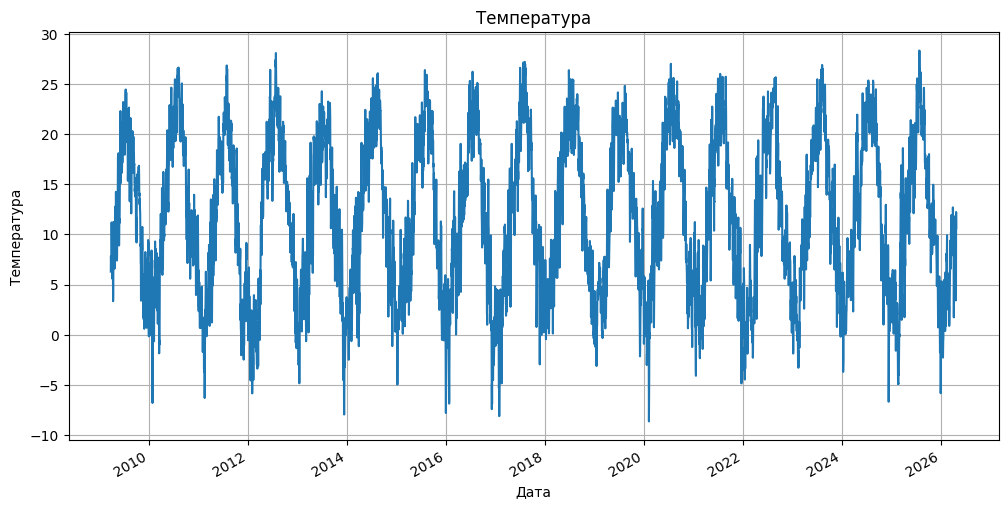

In [23]:
df['T'].plot(figsize=(12,6))
plt.title('Температура')
plt.xlabel('Дата')
plt.ylabel('Температура')
plt.grid(True)
plt.show()

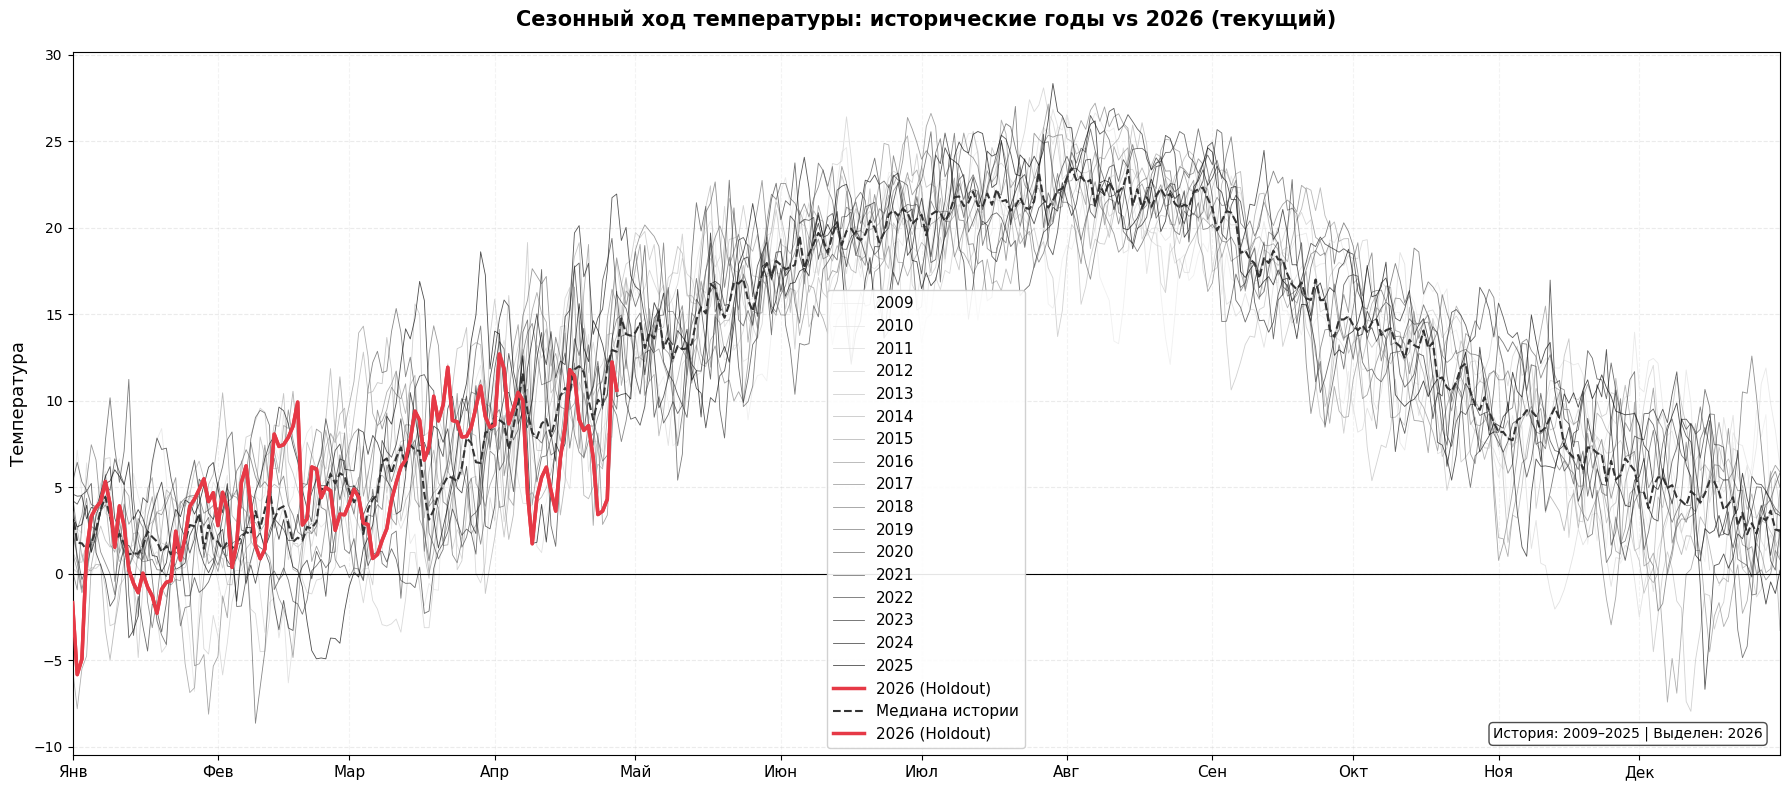

In [24]:
df['year'] = df.index.year
df['month'] = df.index.month
df['day'] = df.index.day
df['day_of_year'] = df.index.dayofyear

# Убираем 29 февраля для единообразия длин (опционально)
df = df[~((df.index.month == 2) & (df.index.day == 29))]

# ---------------------------------------------------
# 2. НАСТРОЙКА ЦВЕТОВ И ВЫДЕЛЕНИЙ
# ---------------------------------------------------
HOLDOUT_YEAR = 2026

# Все года, кроме выделяемого
historical_years = sorted([y for y in df['year'].unique() if y != HOLDOUT_YEAR])

# Цветовая гамма: исторические годы — серые/приглушённые оттенки, holdout — яркий
cmap_hist = plt.get_cmap('Greys', len(historical_years) + 3)  # +3 чтобы не брать крайние светлые

# ---------------------------------------------------
# 3. ПОСТРОЕНИЕ ГРАФИКА
# ---------------------------------------------------
fig, ax = plt.subplots(figsize=(18, 8))

# --- Исторические линии ---
for i, year in enumerate(historical_years):
    yeardata = df[df['year'] == year].sort_values('day_of_year')
    
    if len(yeardata) < 30:
        continue
    
    # Оттенок серого: от тёмного к светлому (старые — светлее, новые — темнее)
    grey_idx = int((i / max(1, len(historical_years)-1)) * (len(historical_years)-1)) + 2
    color = cmap_hist(grey_idx + 1)
    
    ax.plot(yeardata['day_of_year'], 
            yeardata['T'], 
            color=color,
            linewidth=0.6,
            alpha=0.7,
            label=str(year) if len(historical_years) <= 20 else "")

# --- Выделенный 2025 год ---
yeardata_holdout = df[df['year'] == HOLDOUT_YEAR].sort_values('day_of_year')

if len(yeardata_holdout) > 0:
    ax.plot(yeardata_holdout['day_of_year'], 
            yeardata_holdout['T'], 
            color='#E63946',      # ярко-красный
            linewidth=2.5,
            alpha=1.0,
            label=f'{HOLDOUT_YEAR} (Holdout)',
            zorder=10)            # поверх всех линий

# ---------------------------------------------------
# 4. ОСИ И МЕТКИ
# ---------------------------------------------------
# Месячные метки на оси X (первое число каждого месяца)
month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 
                'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']

ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels, fontsize=11)
ax.set_xlim(1, 365)

ax.set_ylabel('Температура', fontsize=13)
ax.set_title(f'Сезонный ход температуры: исторические годы vs {HOLDOUT_YEAR} (текущий)', 
             fontsize=15, pad=18, fontweight='bold')

# Горизонтальная нулевая линия
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')

# Сетка
ax.grid(True, linestyle='--', alpha=0.25, axis='y')
ax.grid(True, linestyle='--', alpha=0.15, axis='x')

# ---------------------------------------------------
# 5. ЛЕГЕНДА
# ---------------------------------------------------
# Если исторических лет много — показываем только первый, последний, медианный
if len(historical_years) > 12:
    handles = []
    
    # Медиана по дням
    pivot = df[df['year'] != HOLDOUT_YEAR].pivot_table(
        values='T', index='day_of_year', columns='year', aggfunc='mean'
    )
    
    # Вычисляем медиану
    if not pivot.empty:
        median_curve = pivot.median(axis=1)
        
        
        # Медианная линия
        ax.plot(pivot.index, median_curve, 
                color='#333333', linewidth=1.5, linestyle='--', 
                label='Медиана истории', zorder=5)
    
    # Holdout
    if len(yeardata_holdout) > 0:
        ax.plot(yeardata_holdout['day_of_year'], 
                yeardata_holdout['T'], 
                color='#E63946', linewidth=2.5, label=f'{HOLDOUT_YEAR} (Holdout)')
    
    ax.legend(fontsize=11, loc='lower center', framealpha=0.9)
else:
    # Если лет мало — показываем все
    ax.legend(fontsize=9, loc='lower center', ncol=2, framealpha=0.85)

# ---------------------------------------------------
# 6. ПОДПИСЬ ДИАПАЗОНА (XX–YY)
# ---------------------------------------------------
# Добавим текстовую аннотацию с годами исторического диапазона
hist_min_year = min(historical_years) if historical_years else '—'
hist_max_year = max(historical_years) if historical_years else '—'
ax.text(0.99, 0.02, f'История: {hist_min_year}–{hist_max_year} | Выделен: {HOLDOUT_YEAR}',
        transform=ax.transAxes, fontsize=10, ha='right', va='bottom',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

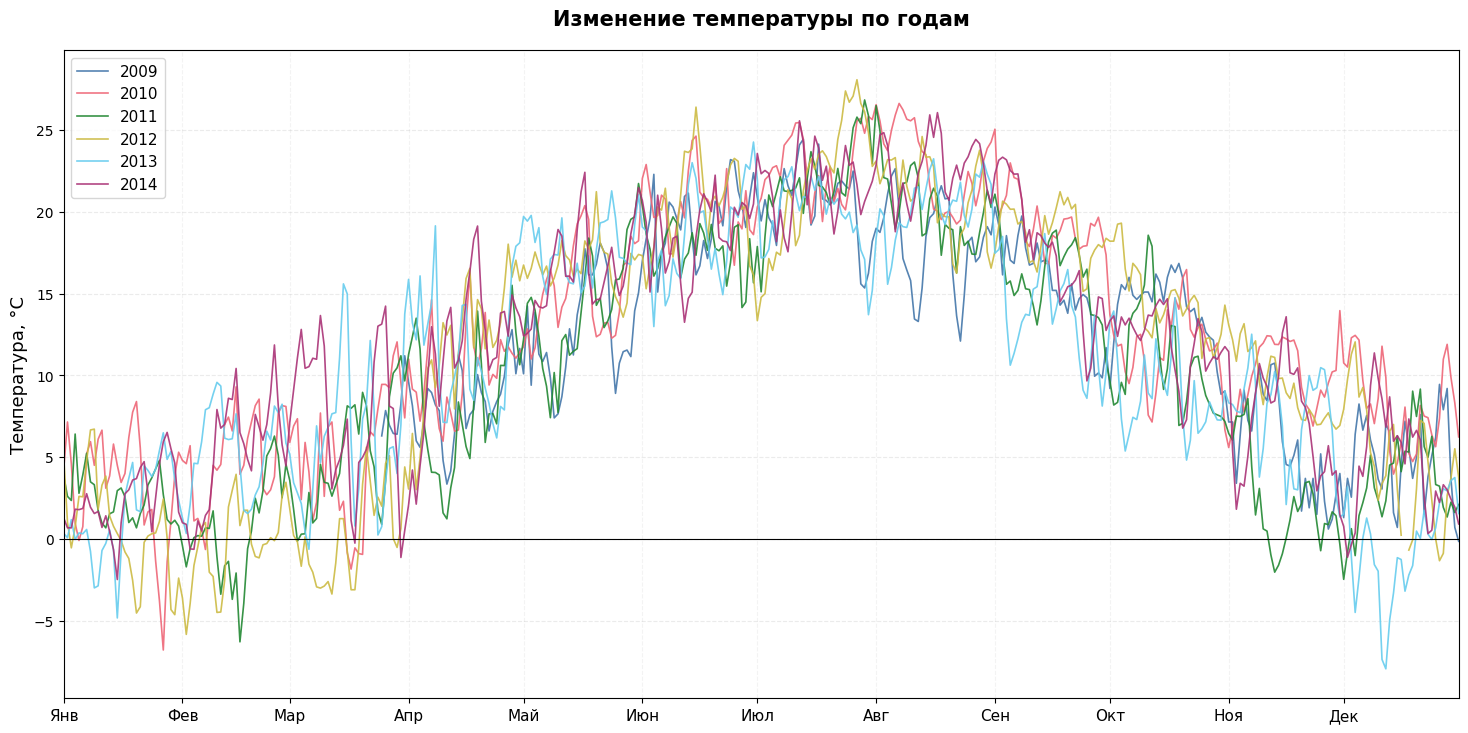

In [25]:

all_years = sorted(df['year'].unique())

years = all_years[:6]

# Paul Tol "Bright" — 7 контрастных цветов
paul_tol_bright = [
    '#4477AA',  # синий
    '#EE6677',  # красный
    '#228833',  # зелёный
    '#CCBB44',  # жёлтый
    '#66CCEE',  # голубой
    '#AA3377',  # пурпурный
    '#BBBBBB',  # серый
]

# Выбираем нужное количество
colors = paul_tol_bright[:len(years)]

# ---------------------------------------------------
# 3. ПОСТРОЕНИЕ ГРАФИКА
# ---------------------------------------------------
fig, ax = plt.subplots(figsize=(18, 8))

for i, year in enumerate(years):
    yeardata = df[df['year'] == year].sort_values('day_of_year')
    
    if len(yeardata) < 30:
        continue
    
    ax.plot(yeardata['day_of_year'], 
            yeardata['T'], 
            color=colors[i],
            linewidth=1.2,
            alpha=0.9,
            label=str(year))

# ---------------------------------------------------
# 4. ОСИ И МЕТКИ
# ---------------------------------------------------
month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 
                'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']

ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels, fontsize=11)
ax.set_xlim(1, 365)

ax.set_ylabel('Температура, °C', fontsize=13)
ax.set_title('Изменение температуры по годам', 
             fontsize=15, pad=18, fontweight='bold')

# Горизонтальная нулевая линия
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')

# Сетка
ax.grid(True, linestyle='--', alpha=0.25, axis='y')
ax.grid(True, linestyle='--', alpha=0.15, axis='x')

# ---------------------------------------------------
# 5. ЛЕГЕНДА
# ---------------------------------------------------
ax.legend(
    fontsize=11, 
    loc='upper left', 
)

plt.subplots_adjust(top=0.92)    # освобождаем место сверху под легенду
plt.show()

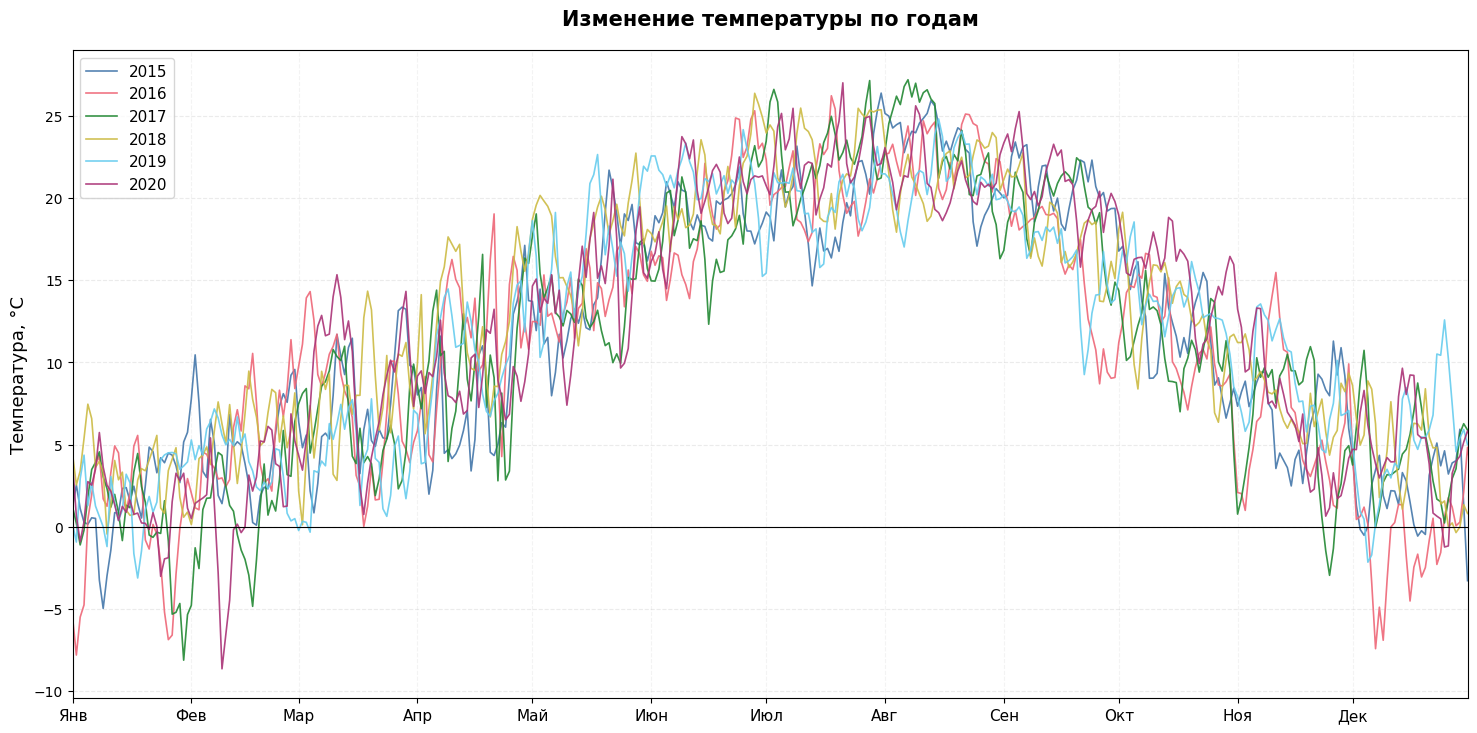

In [26]:
years = all_years[6:12]

# Paul Tol "Bright" — 7 контрастных цветов
paul_tol_bright = [
    '#4477AA',  # синий
    '#EE6677',  # красный
    '#228833',  # зелёный
    '#CCBB44',  # жёлтый
    '#66CCEE',  # голубой
    '#AA3377',  # пурпурный
    '#BBBBBB',  # серый
]

# Выбираем нужное количество
colors = paul_tol_bright[:len(years)]

# ---------------------------------------------------
# 3. ПОСТРОЕНИЕ ГРАФИКА
# ---------------------------------------------------
fig, ax = plt.subplots(figsize=(18, 8))

for i, year in enumerate(years):
    yeardata = df[df['year'] == year].sort_values('day_of_year')
    
    if len(yeardata) < 30:
        continue
    
    ax.plot(yeardata['day_of_year'], 
            yeardata['T'], 
            color=colors[i],
            linewidth=1.2,
            alpha=0.9,
            label=str(year))

# ---------------------------------------------------
# 4. ОСИ И МЕТКИ
# ---------------------------------------------------
month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 
                'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']

ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels, fontsize=11)
ax.set_xlim(1, 365)

ax.set_ylabel('Температура, °C', fontsize=13)
ax.set_title('Изменение температуры по годам', 
             fontsize=15, pad=18, fontweight='bold')

# Горизонтальная нулевая линия
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')

# Сетка
ax.grid(True, linestyle='--', alpha=0.25, axis='y')
ax.grid(True, linestyle='--', alpha=0.15, axis='x')

# ---------------------------------------------------
# 5. ЛЕГЕНДА
# ---------------------------------------------------
ax.legend(
    fontsize=11, 
    loc='upper left'
)

plt.subplots_adjust(top=0.92)    # освобождаем место сверху под легенду
plt.show()

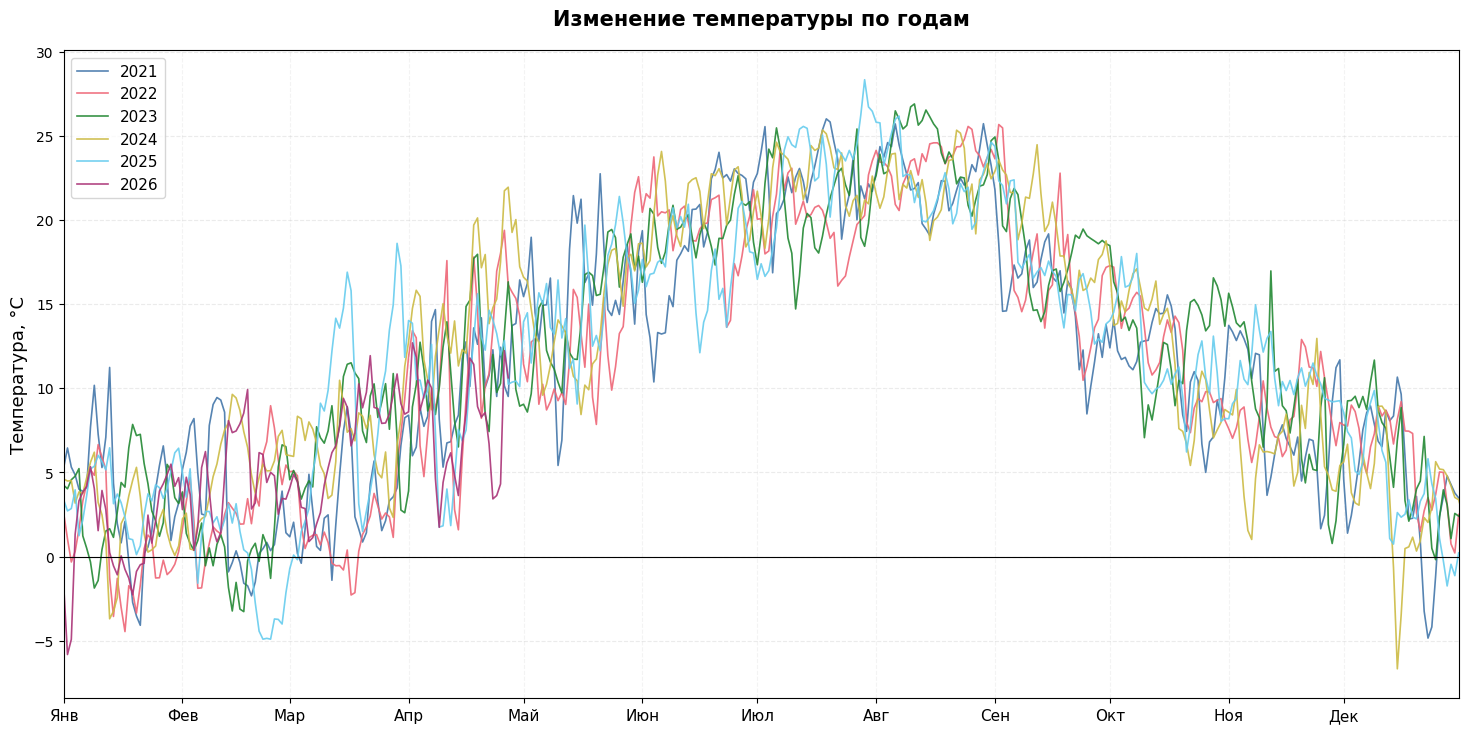

In [27]:
years = all_years[12:]

# Paul Tol "Bright" — 7 контрастных цветов
paul_tol_bright = [
    '#4477AA',  # синий
    '#EE6677',  # красный
    '#228833',  # зелёный
    '#CCBB44',  # жёлтый
    '#66CCEE',  # голубой
    '#AA3377',  # пурпурный
    '#BBBBBB',  # серый
]

# Выбираем нужное количество
colors = paul_tol_bright[:len(years)]

# ---------------------------------------------------
# 3. ПОСТРОЕНИЕ ГРАФИКА
# ---------------------------------------------------
fig, ax = plt.subplots(figsize=(18, 8))

for i, year in enumerate(years):
    yeardata = df[df['year'] == year].sort_values('day_of_year')
    
    if len(yeardata) < 30:
        continue
    
    ax.plot(yeardata['day_of_year'], 
            yeardata['T'], 
            color=colors[i],
            linewidth=1.2,
            alpha=0.9,
            label=str(year))

# ---------------------------------------------------
# 4. ОСИ И МЕТКИ
# ---------------------------------------------------
month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 
                'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']

ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels, fontsize=11)
ax.set_xlim(1, 365)

ax.set_ylabel('Температура, °C', fontsize=13)
ax.set_title('Изменение температуры по годам', 
             fontsize=15, pad=18, fontweight='bold')

# Горизонтальная нулевая линия
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')

# Сетка
ax.grid(True, linestyle='--', alpha=0.25, axis='y')
ax.grid(True, linestyle='--', alpha=0.15, axis='x')

# ---------------------------------------------------
# 5. ЛЕГЕНДА
# ---------------------------------------------------
ax.legend(
    fontsize=11, 
    loc='upper left'
)

plt.subplots_adjust(top=0.92)    # освобождаем место сверху под легенду
plt.show()

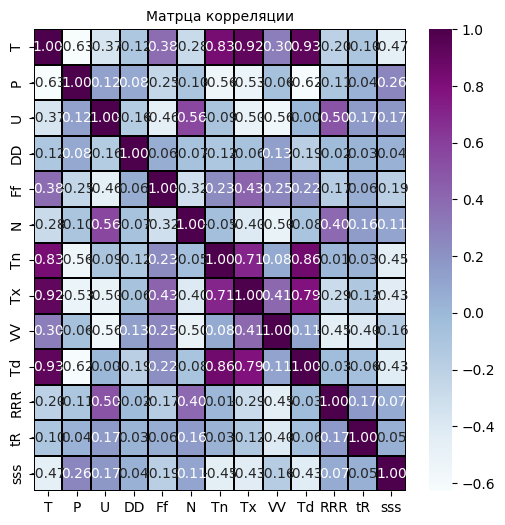

In [28]:
# проверим корреляцию признаков
plt.figure(figsize=(6, 6))
correlation_matrix = df_daily.corr(numeric_only=True)
plt.title('Матрца корреляции', fontsize = 10)
sns.heatmap(correlation_matrix, 
            linewidths=0.1,
            linecolor='black',
            annot=True, 
            fmt='.2f', 
            cmap='BuPu')
plt.show()

In [29]:
for lag in range(1,30):
    df_daily[f'lag_sss_{lag}'] = df_daily['sss'].shift(lag)
    df_daily[f'lag_T_{lag}'] = df_daily['T'].shift(lag)

df_daily['month'] = df_daily.index.month
df_daily['month'] = df_daily['month'].map({5: 1, 6: 1, 7: 1, 8: 1, 4: 2, 9: 1, 10: 2, 3: 3, 11: 3, 12: 4, 1:4, 2:4})

df_daily = df_daily.dropna()
df_daily.head()

,T,P,U,DD,Ff,N,Tn,Tx,VV,Td,...,lag_T_25,lag_sss_26,lag_T_26,lag_sss_27,lag_T_27,lag_sss_28,lag_T_28,lag_sss_29,lag_T_29,month
Время,,,,,,,,,,,,,,,,,,,,,
2009-04-23,7.80,759.75,46.5,2.5,1.0,60.0,2.1,19.5,35.0,-2.90,...,6.40,0.0,6.45,0.0,6.95,0.0,7.85,0.0,6.30,2
2009-04-24,8.40,763.40,63.5,-2.5,1.5,85.0,2.8,13.6,35.0,1.90,...,8.25,0.0,6.40,0.0,6.45,0.0,6.95,0.0,7.85,2
2009-04-25,8.85,764.60,75.0,-3.5,1.5,12.5,3.6,14.6,35.0,4.65,...,11.20,0.0,8.25,0.0,6.40,0.0,6.45,0.0,6.95,2
2009-04-26,9.95,766.80,64.5,0.5,1.0,2.5,3.9,15.5,35.0,3.50,...,9.60,0.0,11.20,0.0,8.25,0.0,6.40,0.0,6.45,2
2009-04-27,11.90,766.25,51.5,-2.5,1.5,0.0,3.0,19.5,35.0,2.25,...,8.15,0.0,9.60,0.0,11.20,0.0,8.25,0.0,6.40,2


In [41]:
df_train = df_daily['2010-10-01' : '2026-01-01']
df_valid = df_daily['2026-01-01' : '2026-02-01']
df_test = df_daily['2026-02-01' : '2026-02-15']

scaler = MinMaxScaler()

index = df_train.index
columns = df_train.columns
df_train_scaled = pd.DataFrame(scaler.fit_transform(df_train), index=index, columns=columns)
index = df_valid.index
columns = df_valid.columns
df_valid_scaled = pd.DataFrame(scaler.transform(df_valid), index=index, columns=columns)
index = df_test.index
columns = df_test.columns
df_test_scaled = pd.DataFrame(scaler.transform(df_test), index=index, columns=columns)

x_train_sss = df_train_scaled.drop(['sss'], axis=1)
y_train_sss = df_train_scaled['sss']

x_valid_sss = df_valid_scaled.drop(['sss'], axis=1)
y_valid_sss = df_valid_scaled['sss']

x_test_sss = df_test_scaled.drop(['sss'], axis=1)
y_test_sss = df_test_scaled['sss']

x_train_T = df_train_scaled.drop(['T'], axis=1)
y_train_T = df_train_scaled['T']

x_valid_T = df_valid_scaled.drop(['T'], axis=1)
y_valid_T = df_valid_scaled['T']

x_test_T = df_test_scaled.drop(['T'], axis=1)
y_test_T = df_test_scaled['T']

In [31]:
metrics_sss = pd.DataFrame(columns=['Модель', 'R2', 'Mape'])
metrics_T = pd.DataFrame(columns=['Модель', 'R2', 'Mape'])

In [32]:
SEED=42
#Линейная регрессия с L2-регуляризацией
model_ridge_sss = Ridge(random_state = SEED)
model_ridge_T = Ridge(random_state = SEED)
alphas = np.logspace(-3, 3, 50)  # 50 точек от 10^-3 до 10^3
parametrs = {'alpha': alphas }
cv = TimeSeriesSplit(n_splits=5)

grid = GridSearchCV(model_ridge_sss, parametrs, cv=cv, scoring='r2', n_jobs=-1)
grid.fit(x_train_sss, y_train_sss)

print('\033[1mОптимальные параметры для sss:\033[0m ', grid.best_params_)

model_ridge_sss.set_params(**grid.best_params_)       
model_ridge_sss.fit(x_train_sss, y_train_sss)         
predictions = model_ridge_sss.predict(x_valid_sss)

r2 = r2_score(y_valid_sss, predictions)
mape = mean_absolute_percentage_error(y_valid_sss, predictions)

metrics_sss.loc[0] = ['Ridge', r2, mape]
print('\033[1mMAPE на валидационной выборке для sss:\033[0m ', mape, 
      '\n\033[1mR2 на валидационной выборке для sss:\033[0m ', r2)




grid = GridSearchCV(model_ridge_T, parametrs, cv=cv, scoring='r2', n_jobs=-1)
grid.fit(x_train_T, y_train_T)

print('\033[1mОптимальные параметры для T:\033[0m ', grid.best_params_)

model_ridge_T.set_params(**grid.best_params_)       
model_ridge_T.fit(x_train_T, y_train_T)         
predictions = model_ridge_T.predict(x_valid_T)

r2 = r2_score(y_valid_T, predictions)
mape = mean_absolute_percentage_error(y_valid_T, predictions)

metrics_T.loc[0] = ['Ridge', r2, mape]
print('\033[1mMAPE на валидационной выборке для T:\033[0m ', mape, 
      '\n\033[1mR2 на валидационной выборке для T:\033[0m ', r2)

Оптимальные параметры для sss:  {'alpha': np.float64(0.868511373751352)}
MAPE на валидационной выборке для sss:  39935703313638.79 
R2 на валидационной выборке для sss:  0.769206219682764
Оптимальные параметры для T:  {'alpha': np.float64(0.016768329368110083)}
MAPE на валидационной выборке для T:  0.024374150439155615 
R2 на валидационной выборке для T:  0.9812813868051097


In [33]:
# тестируем модель RandomForest
parametrs = {'n_estimators': [100, 300, 500],
             'max_depth': [5, 10, 15] }
model_rf_sss = RandomForestRegressor(random_state = SEED)
model_rf_T = RandomForestRegressor(random_state = SEED)
cv = TimeSeriesSplit(n_splits=5)

grid = GridSearchCV(model_rf_sss, parametrs, cv=cv, scoring='r2', n_jobs=-1)
grid.fit(x_train_sss, y_train_sss)

print('\033[1mОптимальные параметры для sss:\033[0m ', grid.best_params_)

model_rf_sss.set_params(**grid.best_params_)       
model_rf_sss.fit(x_train_sss, y_train_sss)          
predictions = model_rf_sss.predict(x_valid_sss)

mape = mean_absolute_percentage_error(y_valid_sss, predictions)
r2 = r2_score(y_valid_sss, predictions)
metrics_sss.loc[1] = ['Random Forest', r2, mape]

print('\033[1mMAPE на валидационной выборке для sss:\033[0m ', mape, 
      '\n\033[1mR2 на валидационной выборке для sss:\033[0m ', r2)



grid = GridSearchCV(model_rf_T, parametrs, cv=cv, scoring='r2', n_jobs=-1)
grid.fit(x_train_T, y_train_T)

print('\033[1mОптимальные параметры для T:\033[0m ', grid.best_params_)

model_rf_T.set_params(**grid.best_params_)       
model_rf_T.fit(x_train_T, y_train_T)          
predictions = model_rf_T.predict(x_valid_T)

mape = mean_absolute_percentage_error(y_valid_T, predictions)
r2 = r2_score(y_valid_T, predictions)
metrics_T.loc[1] = ['Random Forest', r2, mape]

print('\033[1mMAPE на валидационной выборке для T:\033[0m ', mape, 
      '\n\033[1mR2 на валидационной выборке для T:\033[0m ', r2)

Оптимальные параметры для sss:  {'max_depth': 15, 'n_estimators': 500}
MAPE на валидационной выборке для sss:  4977639166468.173 
R2 на валидационной выборке для sss:  0.8519126444297866
Оптимальные параметры для T:  {'max_depth': 15, 'n_estimators': 300}
MAPE на валидационной выборке для T:  0.02694777468944627 
R2 на валидационной выборке для T:  0.9662248580649646


In [34]:
# тестируем модель GradientBoosting
parametrs = {'n_estimators': [100, 200, 500],
             'max_depth':  [3, 5, 10, 15],
             'learning_rate': [0.01, 0.1, 0.5]}
model_gb_sss = GradientBoostingRegressor(random_state=SEED)
cv = TimeSeriesSplit(n_splits=5)

grid = GridSearchCV(model_gb_sss, parametrs, cv=cv, scoring='r2', n_jobs=-1)
grid.fit(x_train_sss, y_train_sss)

print('\033[1mОптимальные параметры для sss:\033[0m ', grid.best_params_)

model_gb_sss.set_params(**grid.best_params_)       
model_gb_sss.fit(x_train_sss, y_train_sss)          
predictions = model_gb_sss.predict(x_valid_sss)

mape = mean_absolute_percentage_error(y_valid_sss, predictions)
r2 = r2_score(y_valid_sss, predictions)
metrics_sss.loc[2] = ['GradientBoosting', r2, mape]

print('\033[1mMAPE на валидационной выборке для sss:\033[0m ', mape, 
      '\n\033[1mR2 на валидационной выборке для sss:\033[0m ', r2)

Оптимальные параметры для sss:  {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500}
MAPE на валидационной выборке для sss:  7635559669542.048 
R2 на валидационной выборке для sss:  0.8661681203464876


In [35]:
model_gb_T = GradientBoostingRegressor(random_state=SEED)
cv = TimeSeriesSplit(n_splits=5)

grid = GridSearchCV(model_gb_T, parametrs, cv=cv, scoring='r2',n_jobs=-1)
grid.fit(x_train_T, y_train_T)

print('\033[1mОптимальные параметры для T:\033[0m ', grid.best_params_)

model_gb_T.set_params(**grid.best_params_)       
model_gb_T.fit(x_train_T, y_train_T)          
predictions = model_gb_T.predict(x_valid_T)

mape = mean_absolute_percentage_error(y_valid_T, predictions)
r2 = r2_score(y_valid_T, predictions)
metrics_T.loc[2] = ['GradientBoosting', r2, mape]

print('\033[1mMAPE на валидационной выборке для T:\033[0m ', mape, 
      '\n\033[1mR2 на валидационной выборке для T:\033[0m ', r2)

Оптимальные параметры для T:  {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500}
MAPE на валидационной выборке для T:  0.02204687696146736 
R2 на валидационной выборке для T:  0.9794868365354776


In [47]:
metrics_sss

,Модель,R2,Mape
0,Ridge,0.769206,3.993570e+13
1,Random Forest,0.851913,4.977639e+12
2,GradientBoosting,0.866168,7.635560e+12


In [48]:
metrics_T

,Модель,R2,Mape
0,Ridge,0.981281,0.024374
1,Random Forest,0.966225,0.026948
2,GradientBoosting,0.979487,0.022047


In [42]:

model_sss = GradientBoostingRegressor(learning_rate=0.01, max_depth=3, n_estimators=500, random_state=SEED)
x_train_sss_2 = pd.concat([x_train_sss, x_valid_sss], axis=0)
y_train_sss_2 = pd.concat([y_train_sss, y_valid_sss], axis=0)

predictions = pd.DataFrame(columns=['sss'], index=x_test_sss.index)
features_test = pd.DataFrame(scaler.transform(df_daily.loc[['2026-01-31']]),index=df_daily.loc[['2026-01-31']].index, columns=df_daily.loc[['2026-01-31']].columns).drop(['sss'],axis=1)


for i in range(len(x_test_sss)):
    y_train_sss_2 = y_train_sss_2.shift(-1).dropna()
    x_train_sss_2 = x_train_sss_2[:-1]
    model_sss.fit(x_train_sss_2, y_train_sss_2)
    y_pred = model_sss.predict(features_test)
    predictions.iloc[i] = y_pred
    
mape = mean_absolute_percentage_error(y_test_sss, predictions)
r2 = r2_score(y_test_sss, predictions)

print('\033[1mMAPE на тестовой выборке:\033[0m ', mape, 
      '\n\033[1mR2 на тестовой выборке:\033[0m ', r2)

MAPE на тестовой выборке:  0.8278534145838208 
R2 на тестовой выборке:  0.7554948934115653


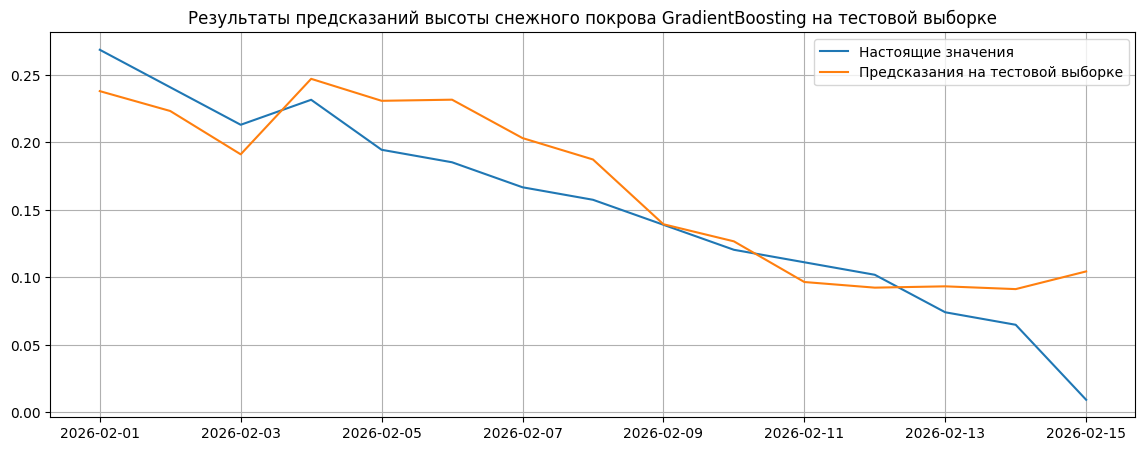

In [44]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_sss, label='Настоящие значения')
plt.plot(predictions, label='Предсказания на тестовой выборке')
plt.title('Результаты предсказаний высоты снежного покрова GradientBoosting на тестовой выборке')
plt.legend()
plt.grid()
plt.show()

In [45]:
model_T = Ridge(alpha=0.016768329368110083,random_state=SEED)
x_train_T_2 = pd.concat([x_train_T, x_valid_T], axis=0)
y_train_T_2 = pd.concat([y_train_T, y_valid_T], axis=0)

predictions = pd.DataFrame(columns=['T'], index=x_test_T.index)
features_test = pd.DataFrame(scaler.transform(df_daily.loc[['2026-01-31']]),index=df_daily.loc[['2026-01-31']].index, columns=df_daily.loc[['2026-01-31']].columns).drop(['T'],axis=1)


for i in range(len(x_test_T)):
    y_train_T_2 = y_train_T_2.shift(-1).dropna()
    x_train_T_2 = x_train_T_2[:-1]
    model_T.fit(x_train_T_2, y_train_T_2)
    y_pred = model_T.predict(features_test)
    predictions.iloc[i] = y_pred
    
mape = mean_absolute_percentage_error(y_test_T, predictions)
r2 = r2_score(y_test_T, predictions)

print('\033[1mMAPE на тестовой выборке:\033[0m ', mape, 
      '\n\033[1mR2 на тестовой выборке:\033[0m ', r2)

MAPE на тестовой выборке:  0.17375058289265752 
R2 на тестовой выборке:  0.018803952126897783


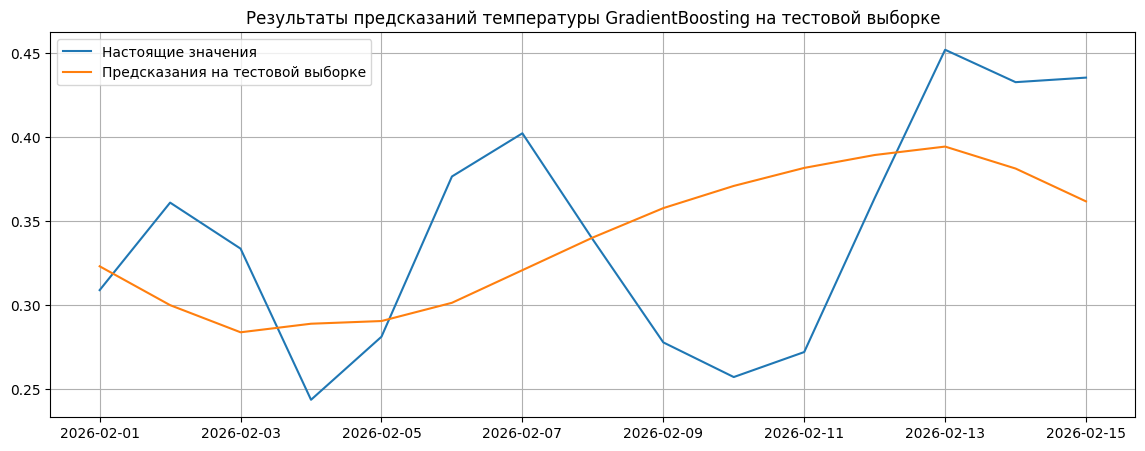

In [46]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_T, label='Настоящие значения')
plt.plot(predictions, label='Предсказания на тестовой выборке')
plt.title('Результаты предсказаний температуры GradientBoosting на тестовой выборке')
plt.legend()
plt.grid()
plt.show()